In [391]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.svm import SVC         # polynomial model
from sklearn.svm import LinearSVC   # linear model
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [392]:
url = 'winequality-white.csv'
df = pd.read_csv(url, sep=";", engine='pyarrow')

In [393]:
# 1.1 Load the dataset and display the first five rows
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [394]:
# 1.3 Convert the target variable into a binary classification problem
df['quality'] = (df['quality'] >=6).astype(int)
df['quality'].dtype
df['quality'].value_counts()

quality
1    3258
0    1640
Name: count, dtype: int64

In [395]:
df.size

58776

In [396]:
df.drop_duplicates(inplace=True)

In [397]:
df.size

47532

In [398]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [399]:
df.shape

(3961, 12)

In [400]:
df.dropna(inplace=True)

In [401]:
df.shape

(3961, 12)

In [402]:
column_list = df.columns
column_list

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [403]:
df.isnull().sum()
# 1.2 Handle any missing values (if present) 
# none present

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [404]:
# 2. Train-Test Split START

X = dfz.drop('quality', axis=1) # training set
y = dfz['quality'] # target

In [405]:
# 2. Train-Test Split END
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

In [406]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.fit_transform(X_test)

In [407]:
dfz = pd.DataFrame(df, columns=['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'])
dfz

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,1
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,1
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,1
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,1


In [408]:
dfz.shape

(3961, 12)

In [409]:
dfz['quality'].value_counts()

quality
1    2613
0    1348
Name: count, dtype: int64

In [410]:
# kNN determining the optimal k value

In [411]:
# Method adapted from: https://www.geeksforgeeks.org/machine-learning/how-to-find-the-optimal-value-of-k-in-knn/
# Purpose: for loop for finding the optimal k value
knn = KNeighborsClassifier()
param_grid = {'n_neighbors': range(1,31)} # why we write it like this?

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1') # what is the meaning of scoring?
grid_search.fit(X_train, y_train)

optimal_k = grid_search.best_params_['n_neighbors']
print(f'The optimal K value is: {optimal_k}')
best_knn = grid_search.best_estimator_
print(f'OR: The optimal K value is: {best_knn}')

if optimal_k < 3:
    print(f'It is likely that at optimal k value of {optimal_k}, the kNN model may be underfitted')

The optimal K value is: 11
OR: The optimal K value is: KNeighborsClassifier(n_neighbors=11)


The optimal K value is: 20


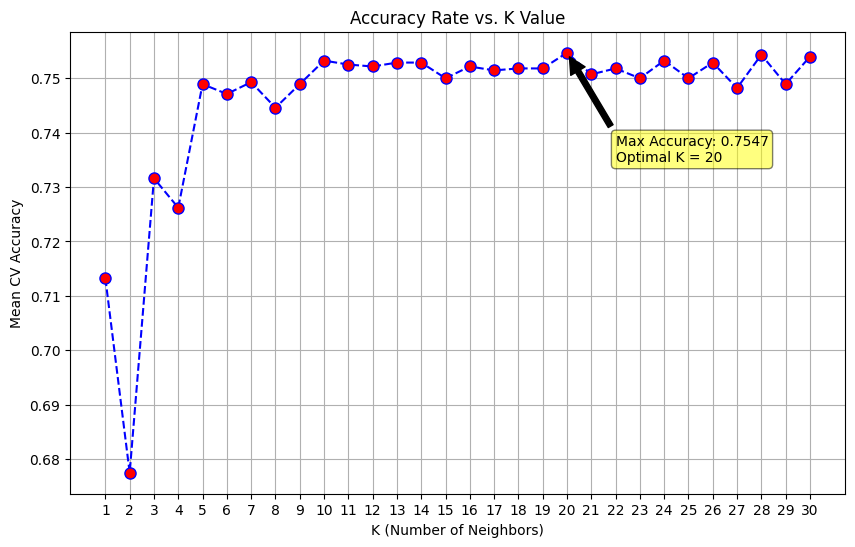

In [412]:
# AI GENERATED CODE: gemini.google.com
# TEMPORARY

# 2. Setup KNN and Parameter Grid
knn = KNeighborsClassifier()
param_grid = {'n_neighbors': range(1, 31)} 

# 3. Run Grid Search (Cross-Validation = 5)
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# 4. Extract Results
optimal_k = grid_search.best_params_['n_neighbors']
mean_scores = grid_search.cv_results_['mean_test_score']
k_values = range(1, 31)

# 5. Print Results
print(f'The optimal K value is: {optimal_k}')

if optimal_k < 3:
    print(f'Note: At k={optimal_k}, the model may be overfitted (too sensitive to noise).')

# 6. Create the Graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, mean_scores, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)

# Add annotation for the Max Value
plt.annotate(f'Max Accuracy: {grid_search.best_score_:.4f}\nOptimal K = {optimal_k}', 
             xy=(optimal_k, grid_search.best_score_), 
             xytext=(optimal_k + 2, grid_search.best_score_ - 0.02),
             arrowprops=dict(facecolor='black', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

plt.title('Accuracy Rate vs. K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [413]:
models = {
    "kNN": KNeighborsClassifier(n_neighbors=optimal_k),
}

resultskNN = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultskNN[name] = accuracy_score(y_test, y_pred)

resultskNN

{'kNN': 0.7645079899074853}

In [414]:
# SVM: Experimentation with different kernel functions (linear, polynomial, RBF) 
# and select the best kernel using cross-validation.

In [415]:
# Code referenced: https://scikit-learn.org/stable/modules/svm.html
# Purpose: for identifying different SVM models

models = {
    "LinearSVC": SVC(kernel="linear"),
    "RBF SVC": SVC(kernel="rbf", gamma=0.7),
    "Polynomial SVC": SVC(kernel="poly", degree=3),
}

resultsSVC = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultsSVC[name] = accuracy_score(y_test, y_pred)

resultsSVC

{'LinearSVC': 0.7510513036164844,
 'RBF SVC': 0.7434819175777965,
 'Polynomial SVC': 0.7375946173254836}

In [416]:
models = {
    "kNN": KNeighborsClassifier(n_neighbors=optimal_k),
}

resultsLDA = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultsLDA[name] = accuracy_score(y_test, y_pred)

resultsLDA

{'kNN': 0.7645079899074853}

In [417]:
# Evaluation of models

In [418]:
modelsAll = {
    "LDA": LinearDiscriminantAnalysis(),
    "LinearSVC": SVC(kernel="linear"),
    "RBF SVC": SVC(kernel="rbf", gamma=0.7),
    "Polynomial SVC": SVC(kernel="poly", degree=3),
    "kNN": KNeighborsClassifier(n_neighbors=optimal_k),
}

resultsAll = {}

for name, model in modelsAll.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultsAll[name] = accuracy_score(y_test, y_pred)

    print(f'This is model: {model} with name: {name}')
    print(classification_report(y_test, y_pred))
    print('')
    print('Here is a confusion matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('----------------------------------')

resultsAll

This is model: LinearDiscriminantAnalysis() with name: LDA
              precision    recall  f1-score   support

           0       0.67      0.51      0.58       405
           1       0.78      0.87      0.82       784

    accuracy                           0.75      1189
   macro avg       0.72      0.69      0.70      1189
weighted avg       0.74      0.75      0.74      1189


Here is a confusion matrix:
[[207 198]
 [101 683]]
----------------------------------
This is model: SVC(kernel='linear') with name: LinearSVC
              precision    recall  f1-score   support

           0       0.67      0.53      0.59       405
           1       0.78      0.87      0.82       784

    accuracy                           0.75      1189
   macro avg       0.73      0.70      0.71      1189
weighted avg       0.74      0.75      0.74      1189


Here is a confusion matrix:
[[213 192]
 [104 680]]
----------------------------------
This is model: SVC(gamma=0.7) with name: RBF SVC
       

{'LDA': 0.7485281749369218,
 'LinearSVC': 0.7510513036164844,
 'RBF SVC': 0.7434819175777965,
 'Polynomial SVC': 0.7375946173254836,
 'kNN': 0.7645079899074853}

In [419]:
# 5.1 Performance Comparison



# Compare Accuracy, Precision, Recall, and F1-Score across k-NN, SVM, and LDA.
# Identify which model achieved the highest overall scores.

# 5.2 Model Strengths
# k-NN: Discuss its simplicity and effectiveness with local patterns.
# SVM: Discuss its power in high-dimensional spaces and kernel flexibility.
# LDA: Discuss its efficiency and performance if classes are linearly separable.

# 5.3 Model Weaknesses
# k-NN: Note sensitivity to noise/outliers and computational cost on large data.
# SVM: Note the "black box" nature and intensive tuning for C and Gamma.
# LDA: Note the reliance on normality assumptions and equal covariance.

# 5.4 Conclusion for Wine Dataset
# Which model is best for predicting wine quality based on these specific chemical features?
# Mention if any model struggled with class imbalance (Good vs. Poor quality).